In [68]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../data/telco_churn_training.csv")
df.shape

(5000, 21)

In [8]:
pd.set_option("display.max_columns", None)
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,3518-HSQPL,Female,0,No,Yes,6,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Credit card (automatic),34.94,188.82,No
1,2779-CINEB,Female,0,No,No,37,Yes,No,Fiber optic,Yes,No,No,Yes,No,No,Month-to-month,No,Credit card (automatic),84.27,3148.70,Yes
2,5059-LYSZS,Female,0,No,No,5,Yes,Yes,Fiber optic,Yes,Yes,No,Yes,No,No,Month-to-month,Yes,Electronic check,90.28,409.79,Yes
3,2849-GTXEL,Male,0,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),93.96,56.38,Yes
4,3977-AQMLH,Male,0,No,No,50,Yes,No,Fiber optic,Yes,Yes,Yes,No,Yes,Yes,Month-to-month,No,Mailed check,104.59,5043.00,Yes
5,2472-KCVUD,Female,0,Yes,Yes,28,Yes,Yes,DSL,No,Yes,Yes,Yes,No,No,One year,Yes,Bank transfer (automatic),71.50,1843.62,No
6,1051-VRYKB,Female,1,Yes,No,1,Yes,Yes,DSL,Yes,No,Yes,Yes,No,No,Month-to-month,No,Credit card (automatic),71.40,269.16,No
7,3153-JMHCJ,Female,0,No,No,18,No,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,18.00,312.31,No
8,2514-CGGEJ,Female,0,Yes,No,29,Yes,Yes,DSL,No,No,Yes,Yes,Yes,No,Month-to-month,Yes,Credit card (automatic),73.51,2161.83,No
9,3040-TXQHL,Female,0,No,No,45,No,No phone service,Fiber optic,No,No,No,Yes,Yes,No,Two year,No,Bank transfer (automatic),70.09,2957.68,No


In [9]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [10]:
df.isnull().sum()

customerID            0
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges        188
Churn                 0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,5000.000000,5000.000000,5000.000000,4812.000000
mean,0.160600,28.721000,68.971528,1988.220131
std,0.367198,21.436648,25.368299,1653.625506
min,0.000000,0.000000,18.000000,11.650000
25%,0.000000,10.000000,54.922500,637.062500
50%,0.000000,24.000000,75.825000,1480.010000
75%,0.000000,45.000000,88.022500,3007.680000
max,1.000000,72.000000,118.000000,7892.330000


In [19]:
df.loc[df["TotalCharges"].idxmin()]

customerID                       2323-LCFEQ
gender                               Female
SeniorCitizen                             0
Partner                                  No
Dependents                               No
tenure                                    2
PhoneService                             No
MultipleLines              No phone service
InternetService                          No
OnlineSecurity          No internet service
OnlineBackup            No internet service
DeviceProtection        No internet service
TechSupport             No internet service
StreamingTV             No internet service
StreamingMovies         No internet service
Contract                     Month-to-month
PaperlessBilling                        Yes
PaymentMethod       Credit card (automatic)
MonthlyCharges                        18.07
TotalCharges                          11.65
Churn                                    No
Name: 1005, dtype: object

In [26]:
count = df.groupby('Churn')["customerID"].count()
count

Churn
No     3122
Yes    1878
Name: customerID, dtype: int64

In [28]:
precentage = count / count.sum() * 100
precentage

Churn
No     62.44
Yes    37.56
Name: customerID, dtype: float64

In [34]:
df["Churn"].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [35]:
df["Contract"].unique()

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

In [36]:
df["Dependents"].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [37]:
df["DeviceProtection"].unique()

<StringArray>
['No internet service', 'No', 'Yes']
Length: 3, dtype: str

In [38]:
df["InternetService"].unique()

<StringArray>
['No', 'Fiber optic', 'DSL']
Length: 3, dtype: str

In [39]:
df["MonthlyCharges"].unique()

array([34.94, 84.27, 90.28, ..., 80.83, 81.56, 65.38], shape=(3512,))

In [40]:
df["MultipleLines"].unique()

<StringArray>
['Yes', 'No', 'No phone service']
Length: 3, dtype: str

In [41]:
df["OnlineBackup"].unique()

<StringArray>
['No internet service', 'No', 'Yes']
Length: 3, dtype: str

In [42]:
df["OnlineSecurity"].unique()

<StringArray>
['No internet service', 'Yes', 'No']
Length: 3, dtype: str

In [43]:
df["PaperlessBilling"].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [44]:
df["Partner"].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [45]:
df["PaymentMethod"].unique()

<StringArray>
[  'Credit card (automatic)',          'Electronic check',
              'Mailed check', 'Bank transfer (automatic)']
Length: 4, dtype: str

In [47]:
df["PhoneService"].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [48]:
df["SeniorCitizen"].unique()

array([0, 1])

In [49]:
df["StreamingMovies"].unique()

<StringArray>
['No internet service', 'No', 'Yes']
Length: 3, dtype: str

In [50]:
df["StreamingTV"].unique()

<StringArray>
['No internet service', 'No', 'Yes']
Length: 3, dtype: str

In [51]:
df["TechSupport"].unique()

<StringArray>
['No internet service', 'Yes', 'No']
Length: 3, dtype: str

In [52]:
df["TotalCharges"].unique()

array([ 188.82, 3148.7 ,  409.79, ..., 3100.42, 3708.33, 1840.22],
      shape=(4794,))

In [53]:
df["tenure"].unique()

array([ 6, 37,  5,  1, 50, 28, 18, 29, 45, 15, 60, 72, 48, 24, 62, 71, 43,
        0,  2, 66, 46, 27, 31, 13, 22, 55, 10, 23, 21, 61,  4, 12, 39, 19,
       20, 30,  3, 36, 35, 38, 11, 14, 17, 70, 47, 52, 69, 68,  7, 67, 64,
       34, 33, 25,  8, 41, 26,  9, 56, 54, 40, 32, 44, 51, 63, 53, 42, 16,
       49, 59, 57, 65, 58])

In [57]:
df["gender"].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

(0.0, 8000.0)

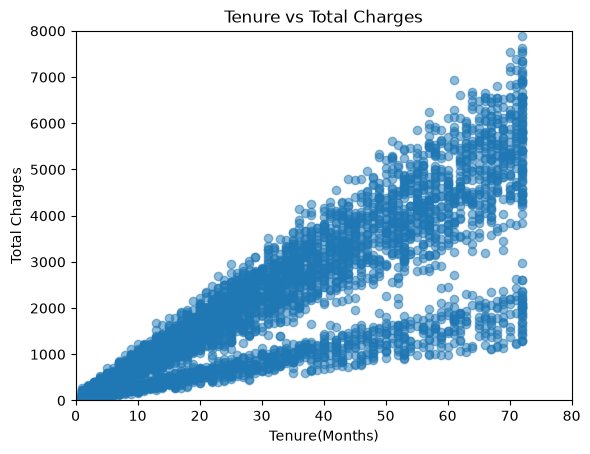

In [65]:
plt.scatter(df["tenure"],df["TotalCharges"],alpha=0.5)
plt.xlabel("Tenure(Months)")
plt.ylabel("Total Charges")
plt.title("Tenure vs Total Charges")
plt.xlim(0, 80)
plt.ylim(0, 8000)


(0.0, 8000.0)

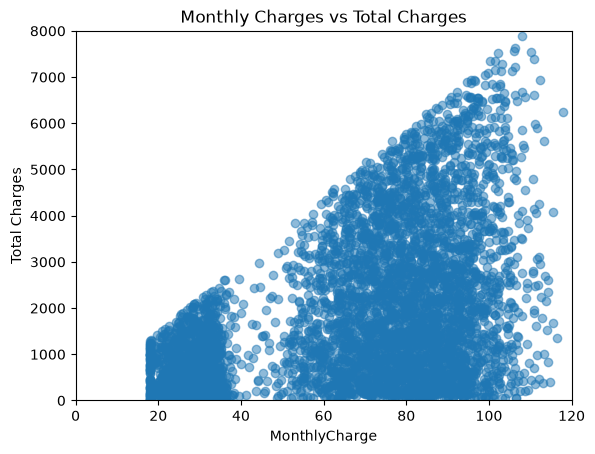

In [66]:
plt.scatter(df["MonthlyCharges"],df["TotalCharges"],alpha=0.5)
plt.xlabel("MonthlyCharge")
plt.ylabel("Total Charges")
plt.title("Monthly Charges vs Total Charges")
plt.xlim(0, 120)
plt.ylim(0, 8000)


<Axes: xlabel='Contract', ylabel='count'>

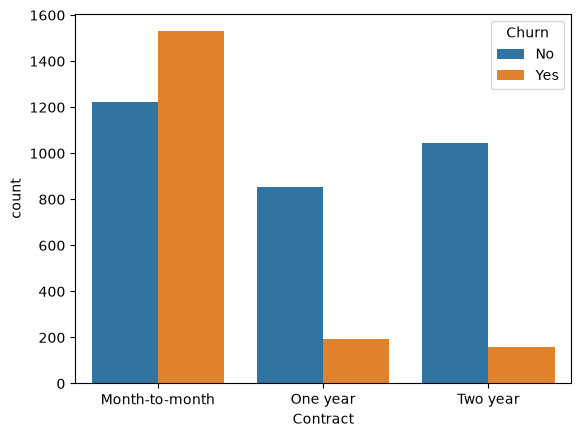

In [71]:
sns.countplot(data=df , x="Contract" , hue="Churn")

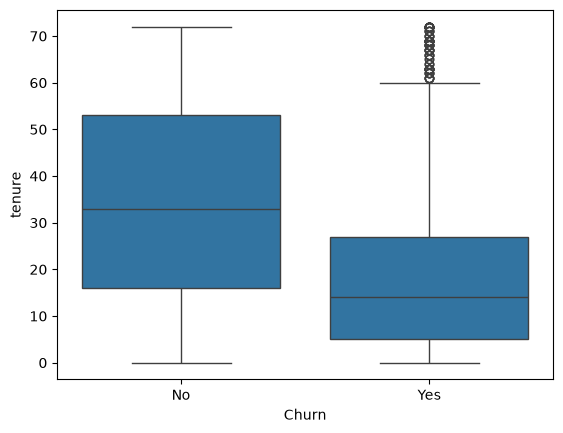

In [72]:
sns.boxplot(data=df, x="Churn", y="tenure")
plt.show()

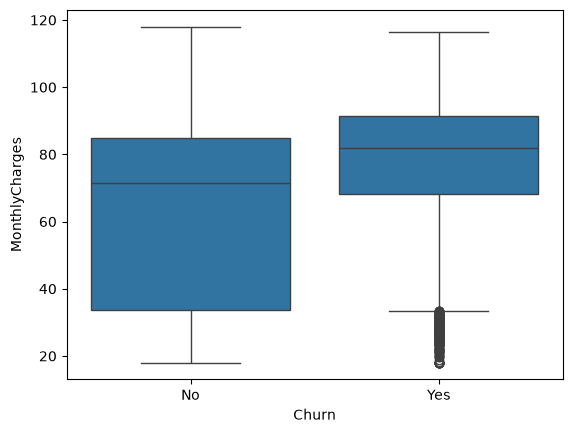

In [73]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.show()

## EDA Conclusions

- `TotalCharges` has 188 missing values.
- In `MonthlyCharges`, there are some unusual values that need attention.
- There is a small imbalance in the target `Churn`.
- There is a clear relationship between `tenure` and `TotalCharges`, and `MonthlyCharges` also has an effect.
- The type of `Contract` is very important. Customers with one-year or two-year contracts are less likely to leave, while month-to-month contracts have the highest churn.
- As `tenure` increases, we keep more customers.
- As `MonthlyCharges` increase, the churn rate tends to increase.